This notebook requires the latest version of the [pyqtl](https://github.com/broadinstitute/pyqtl) package, which can be installed with
```
git clone git@github.com:broadinstitute/pyqtl.git
cd pyqtl
pip3 install -e .
```

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Specify base directory where all files are stored
basedir = '.'  # local working directory; replace with path to your GEO/data download
# All data is available in gs://gtex-calico-p16/locus_figure/
# Almost all files are read directly from this bucket; the only file that must
# be available locally in basedir is:
# gs://gtex-calico-p16/locus_figure/gencode.v26.GRCh38.annotation.p16_locus.gtf

In [3]:
import pandas as pd
import numpy as np
import re
import copy
import glob
import os
import pyBigWig

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'Helvetica', 'svg.fonttype':'none', 'pdf.fonttype':42})
import seaborn as sns

import qtl.annotation
import qtl.plot
import qtl.gtex
colors_df = qtl.gtex.get_colors_df()

matplotlib.rcParams['figure.dpi'] = 72
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

#### Specify locus

In [19]:
# !grep "ENSG00000147889\|ENSG00000240498\|ENSG00000147883\|ENSG00000099810" /resources/gencode.v39.GRCh38.annotation.gtf \
#     > gencode.v39.GRCh38.annotation.p16_locus.gtf
# !gsutil cp gencode.v39.GRCh38.annotation.p16_locus.gtf \
#     gs://gtex-calico-p16/locus_figure/
annot = qtl.annotation.Annotation(f"{basedir}/gencode.v39.GRCh38.annotation.p16_locus.gtf")

Genes parsed: 4


In [26]:
# select specific isoforms for visualization
p16_gene = copy.deepcopy(annot.get_gene('CDKN2A'))
p16_gene.transcripts = [t for t in p16_gene.transcripts if t.id.startswith('ENST00000304494')]
p16_gene.start_pos = p16_gene.transcripts[0].start_pos
p16_gene.end_pos = p16_gene.transcripts[0].end_pos
p16_gene.name = 'p16'

p14_gene = copy.deepcopy(annot.get_gene('CDKN2A'))
p14_gene.transcripts = [t for t in p14_gene.transcripts if t.id.startswith('ENST00000579755')]
p14_gene.start_pos = p14_gene.transcripts[0].start_pos
p14_gene.end_pos = p14_gene.transcripts[0].end_pos
p14_gene.name = 'p14'

p15_gene = copy.deepcopy(annot.get_gene('CDKN2B'))
p15_gene.transcripts = [t for t in p15_gene.transcripts if t.id.startswith('ENST00000276925')]
p15_gene.start_pos = p15_gene.transcripts[0].start_pos
p15_gene.end_pos = p15_gene.transcripts[0].end_pos
p15_gene.name = 'p15'

ANRIL_short_gene = copy.deepcopy(annot.get_gene('CDKN2B-AS1'))
ANRIL_short_gene.transcripts = [t for t in ANRIL_short_gene.transcripts if t.id.startswith('ENST00000584351')]
ANRIL_short_gene.start_pos = ANRIL_short_gene.transcripts[0].start_pos
ANRIL_short_gene.end_pos = ANRIL_short_gene.transcripts[0].end_pos
ANRIL_short_gene.name = 'ANRIL short'

ANRIL_long_gene = copy.deepcopy(annot.get_gene('CDKN2B-AS1'))
ANRIL_long_gene.transcripts = [t for t in ANRIL_long_gene.transcripts if t.id.startswith('ENST00000428597')]
ANRIL_long_gene.start_pos = ANRIL_long_gene.transcripts[0].start_pos
ANRIL_long_gene.end_pos = ANRIL_long_gene.transcripts[0].end_pos
ANRIL_long_gene.name = 'ANRIL long'

mtap_gene = copy.deepcopy(annot.get_gene('MTAP'))
mtap_gene.set_transcripts([mtap_gene.get_mane_transcript()])

p16_locus_genes = [mtap_gene, p16_gene, p14_gene, p15_gene, ANRIL_long_gene, ANRIL_short_gene]

In [27]:
# define locus coordinates
# g1 = annot.get_gene('CDKN2A')
# g2 = annot.get_gene('CDKN2B-AS1')
# region_str = f'{g1.chr}:{g1.start_pos-25000}-{g2.end_pos+100000}'

# region_str = 'chr9:21942753-22221097'
region_str = 'chr9:21750000-22500000'  # expanded region
chrom, pos = region_str.split(':')
start_pos, end_pos = map(int, pos.split('-'))
pos_vec = [f"{chrom}:{i}" for i in range(start_pos, end_pos+1)]

#### Preprocessing — no need to re-run these sections

In [112]:
# UKB LD data from s3://broad-alkesgroup-ukbb-ld/UKBB_LD

ld_region = download_ld(region_str)
liftover_ld(f"{ld_region}.gz")
ukbb_ld_df = load_ld(f"{ld_region}.npz")
ukbb_ld_df = ukbb_ld_df ** 2
pos = np.array([int(i.split('_')[1]) for i in ukbb_ld_df.columns])
m = (pos >= start_pos) & (pos <= end_pos)
ukbb_ld_df = ukbb_ld_df.loc[m, ukbb_ld_df.columns[m]]
# ukbb_ld_df.to_parquet('gs://gtex-calico-p16/locus_figure/UKBB_LD.p16_expanded_locus.parquet')

#### Prepare UKB fine-mapping data

In [167]:
trait_map = {
    'Glucose': 'Metabolic',
    'T2D_BMI': 'Metabolic',
    'T2D'    : 'Metabolic',
    'HbA1c' : 'Metabolic',  # Hemoglobin A1C
    
    'ApoB': 'Lipids',
    'TC':   'Lipids',  # total cholesterol

    'CAD': 'Cardiovascular',
    'PP': 'Cardiovascular',   # pulse pressure
    'DBP': 'Cardiovascular',  # diastolic blood pressure

    'TP': 'Other',  # Total protein
    'Glaucoma_Combined': 'Other',
    'Glaucoma_combined': 'Other',
    'IGF1': 'Other',  # Insulin-like growth factor 1
    'AG': 'Other',  # Albumin/Globulin ratio

    'Plt': 'Hematopoietic',
    'Mono': 'Hematopoietic',
    'Eosino': 'Hematopoietic',
    'Lym': 'Hematopoietic',
    'WBC': 'Hematopoietic',
    'MCV': 'Hematopoietic',  # Mean corpuscular volume (MCV); average volume of red blood cells

    'Height': 'Skeletal',
}

In [168]:
col_s = pd.read_csv('UKBB_94traits_release1.cols',
                    sep='\t', header=None, index_col=0).squeeze('columns')
ukb_df = pd.read_csv('UKBB_94traits_release1.GRCh38_liftover.bed.gz',
                     sep='\t', header=None, names=col_s.index)

ukb_df = ukb_df[ukb_df['chromosome'] == chrom].copy()
ukb_df = ukb_df[ukb_df['cs_id'] != -1]  # drop rows without CS

ukb_df.insert(1, 'position', ukb_df['start']+1)
ukb_df = ukb_df.sort_values(['position'])
ukb_df['variant'] = 'chr' + ukb_df['variant']

ukb_df = ukb_df[(ukb_df['position'] >= start_pos) & (ukb_df['position'] <= end_pos)]

ukb_df.insert(2, 'variant_id', (ukb_df['chromosome'] + '_' + (ukb_df['start']+1).astype(str) + '_'
                                + ukb_df['allele1'] + '_' + ukb_df['allele2'] + '_b38'))

ukb_df.drop(['start', 'end', 'variant', 'allele1', 'allele2', 'minorallele', 'cohort', 'LD_HWE', 'LD_SV',
                   'beta_marginal', 'se_marginal', 'chisq_marginal', 'beta_posterior', 'sd_posterior'], axis=1, inplace=True)
ukb_df.rename(columns={'chromosome': 'chr'}, inplace=True)
ukb_df.reset_index(drop=True, inplace=True)

ukb_df.rename(columns={'trait':'trait_id'}, inplace=True)
ukb_df['trait_category'] = ukb_df['trait_id'].map(trait_map)

# ukb_df.to_csv("gs://gtex-calico-p16/locus_figure/UKBB_94traits_release1.p16_expanded_locus.txt", sep='\t', index=False)

#### Preprocess GTEx LD

In [231]:
vcf = '/resources/vcfs/GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.MAF01.vcf.gz'
import qtl.genotype as gt
genotype_df = gt.get_genotypes_region(vcf, region_str)
gt_df = genotype_df.copy()
gt.impute_mean(gt_df, missing=lambda x: x == -9, verbose=True)
ld_df = pd.DataFrame(np.corrcoef(gt_df.values)**2, index=gt_df.index, columns=gt_df.index)
# ld_df.to_parquet('gs://gtex-calico-p16/locus_figure/GTEx_v8_LD_838participants.p16_expanded_locus.parquet')

  * imputed at least 1 sample in 65 sites


#### Preprocess ATAC-seq from Corces et al., 2016

In [8]:
def get_coverage(region_str, bigwig):
    """Get coverage for selected genomic region from BigWig file"""
    chrom, start_pos, end_pos = re.split(':|-', region_str)
    start_pos = int(start_pos)
    end_pos = int(end_pos)
    bw = pyBigWig.open(bigwig)
    # pyBigWig returns values using BED intervals, e.g., in [start, end)
    c = bw.values(chrom, start_pos-1, end_pos, numpy=True)
    bw.close()
    return c

In [213]:
corces_df = pd.read_excel(f"{basedir}/corces16_atacseq/NG_2016_hg38_bigwigs.xlsx")
# to download:
# corces_df['Link'].to_csv(f"{basedir}/corces16_atacseq/files.txt", sep='\t', header=False, index=False)
# xargs -P 4 -L 1 wget < files.txt
corces_df['path'] = f"{basedir}/corces16_atacseq/" + corces_df['File Name']
corces_df = corces_df[~corces_df['Cell Type'].str.startswith('SU')]
corces_order = ['HSC', 'MPP', 'LMPP', 'CMP', 'GMP', 'MEP', 'Mono',
                'Ery', 'CLP', 'CD4', 'CD8', 'Bcell', 'NK', 'CD34']

# get coverage and collapse
corces_coverage_dict = {}
for k, (celltype, gdf) in enumerate(corces_df.groupby('Cell Type'), 1):
    c = np.c_[[get_coverage(region_str, p) for p in gdf['path']]]
    c[np.isnan(c)] = 0
    corces_coverage_dict[celltype] = c.sum(0)
corces_coverage_dict = {i:corces_coverage_dict[i] for i in corces_order}
corces_df = pd.DataFrame(corces_coverage_dict, index=pos_vec)
# corces_df.to_parquet('gs://gtex-calico-p16/locus_figure/corces16_atacseq/Corces_ATACseq.p16_expanded_locus.parquet')

#### Preprocess ATAC-seq data from ENTEx

In [214]:
# https://www.encodeproject.org/matrix/?type=Experiment&status=released&perturbed=false&searchTerm=gtex&assay_title=ATAC-seq
# grep bigWig ENCODE_GTEX_ATACseq_081620.files.txt > ENCODE_GTEX_ATACseq_081620.bigwig_files.txt
# xargs -P 4 -L 1 curl -O -J -L < ENCODE_GTEX_ATACseq_081620.bigwig_files.txt
# first row of files.txt is metadata
metadata_df = pd.read_csv(f"{basedir}/encode/ENCODE_GTEX_ATACseq_081620.metadata.tsv",
                          sep='\t', index_col=0)
metadata_df = metadata_df[metadata_df['File type'].isin(['bigWig'])]
metadata_df = metadata_df[metadata_df['Output type'] == 'fold change over control']
metadata_df['tissue_id'] = qtl.gtex.get_tissue_id(metadata_df['Biosample term name'].map(qtl.gtex.entex_tissue_map))

ENTEx_ATACseq_dict = {}
for file_id in metadata_df.sort_values('tissue_id').index:
    tissue_id = metadata_df.loc[file_id, 'tissue_id']
    ENTEx_ATACseq_dict[tissue_id] = get_coverage(region_str,
        f"{basedir}/encode/bigwig/{file_id}.bigWig")
ENTEx_df = pd.DataFrame(ENTEx_ATACseq_dict, index=pos_vec)
ENTEx_df.to_parquet('gs://gtex-calico-p16/locus_figure/encode/ENTEx_ATAC.p16_expanded_locus.parquet')

#### Preprocess H3K27ac ChIP-seq data from ENTEx

In [216]:
# grep bigWig ENCODE_GTEx_H3K27ac_081720.files.txt > ENCODE_GTEx_H3K27ac_081720.bigwig_files.txt
df = pd.read_csv(f"gs://gtex-calico-p16/locus_figure/encode_H3K27ac/ENCODE_GTEx_H3K27ac_081720.metadata.tsv",
                 sep='\t', index_col=0)
df = df[(df['File assembly'] == 'GRCh38') & (df['File type'] == 'bigWig')]
df = df[df['Audit WARNING'].isnull() & df['Audit INTERNAL_ACTION'].isnull() & (df['File Status'] == 'released')]
df['tissue_id'] = qtl.gtex.get_tissue_id(df['Biosample term name'].map(qtl.gtex.entex_tissue_map))
df = df[df['Output type'] == 'fold change over control']
df = df[df.columns[~df.isnull().all(0)]]  # drop empty cols

# pick one sample for each tissue, combining biological and/or technical replicates when available
df2 = []
for tissue_id, gdf in df.groupby('tissue_id'):
    if len(gdf) == 1:
        df2.append(gdf)
    elif '1, 2' in gdf['Biological replicate(s)'].values:
        df2.append(gdf[gdf['Biological replicate(s)'] == '1, 2'])
    else:
        assert (gdf['Biological replicate(s)'] == '1').all()
        # pick largest file
        df2.append(gdf.loc[[gdf['Size'].idxmax()]])
df2 = pd.concat(df2)

# with ENCODE files on AWS, direct access no longer seems possible; download instead
# only download samples we need
entex_tracks = [
    'Adrenal_Gland',
    'Artery_Coronary',
    'Colon_Sigmoid',
    'Pancreas',
]
df2 = df2[df2['tissue_id'].isin(entex_tracks)]
# df2['File download URL'].to_csv(f"{basedir}/encode/ENCODE_GTEX_H3K27ac_082424.bigwig_files.txt",
#                                 sep='\t', index=False, header=False)
# xargs -P 4 -L 1 curl -O -J -L < ENCODE_GTEX_H3K27ac_082424.bigwig_files.txt

H3K27ac_dict = {}
# for k,(file_id, url) in enumerate(df['File download URL'].items(), 1):
for k, (file_id, s) in enumerate(df2.iterrows(), 1):
    print(f"\rProcessing {k}/{len(df2)}", end='', flush=True)
    url = f"{basedir}/encode/bigwig/{file_id}.bigWig"
    H3K27ac_dict[f"{file_id}:{s['tissue_id']}"] = get_coverage(region_str, url)
H3K27ac_df = pd.DataFrame(H3K27ac_dict, index=pos_vec)
H3K27ac_df.to_parquet('gs://gtex-calico-p16/locus_figure/encode_H3K27ac/ENCODE_GTEx_H3K27ac.p16_expanded_locus.parquet')

Processing 4/4

#### V10 eQTLs

In [28]:
fm_df = []
for f in sorted(glob.glob("*.v10.eQTLs.SuSiE_summary.parquet")):
    tissue_id = os.path.basename(f).split('.')[0]
    df = pd.read_parquet(f)
    df = df[df['gene_name'].isin(['MTAP', 'CDKN2A', 'CDKN2B', 'CDKN2B-AS1'])].copy()
    if len(df) > 0:
        df['tissue_id'] = tissue_id
        fm_df.append(df)
fm_df = pd.concat(fm_df).reset_index(drop=True)
fm_df['chr'] = fm_df['variant_id'].apply(lambda x: x.split('_')[0])
fm_df['position'] = fm_df['variant_id'].apply(lambda x: int(x.split('_')[1]))
# fm_df.to_parquet('gs://gtex-calico-p16/locus_figure/GTEx_v10.SuSiE_finemapping.parquet')

#### Continue here

#### Load variant sets

In [29]:
ukb_df = pd.read_csv("gs://gtex-calico-p16/locus_figure/UKBB_94traits_release1.p16_expanded_locus.txt", sep='\t')
# drop selected traits
ukb_df = ukb_df[~ukb_df['trait_id'].isin(
    ['TC', 'WBC', 'DBP', 'T2D_BMI', 'Glucose', 'TP', 'Height', 'Plt', 'Mono', 'MCV', 'Eosino']
)]
ukb_df['trait_id'] = ukb_df['trait_id'].str.replace('_Combined', '')  # rename
# sort order
order = ['HbA1c', 'T2D', 'ApoB', 'CAD', 'PP', 'Lym', 'AG', 'Glaucoma', 'IGF1']
ukb_df['trait_id'] = pd.Categorical(ukb_df['trait_id'], categories=order, ordered=True)
ukb_df = ukb_df.sort_values(['trait_id', 'position'])

# TC: total cholesterol
# PP: pulse pressure
# DBP: diastolic blood pressure
# TP: total protein
# IGF1: insulin-like growth factor 1
# AG: albumin/globulin ratio
# MCV: mean corpuscular volume

gtex_pip_df = pd.read_parquet('gs://gtex-calico-p16/locus_figure/GTEx_v10.SuSiE_finemapping.parquet')
gtex_pip_df['trait_category'] = colors_df.loc[gtex_pip_df['tissue_id'], 'tissue_abbrv'].values
# gtex_pip_df['trait_id'] = gtex_pip_df['trait_category'] + ' - ' + gtex_pip_df['gene_name']
gtex_pip_df['trait_id'] = gtex_pip_df['tissue_id'].map(colors_df['tissue_title']) + ' - ' + gtex_pip_df['gene_name']

# not fine-mapped, but formatted as if to fit plot structure:
# pituitary_pip_df = pd.read_csv("gs://gtex-calico-p16/locus_figure/pituitary_dialout.txt", sep='\t')
# blood eQTLs from eQTLGen, ImmuNexUT, macrophages
blood_pip_df = pd.read_csv('gs://gtex-calico-p16/locus_figure/blood_eqtls.txt', sep='\t')

In [30]:
# lead variants from GWAS catalog
# locus_gwas_pip_df = pd.read_csv('gs://gtex-calico-p16/locus_figure/GWAS_Catalog_variants.txt', sep='\t')
locus_gwas_pip_df = pd.read_csv('gs://gtex-calico-p16/locus_figure/GWAS_Catalog_variants_111124.txt', sep='\t')
# drop selected traits
locus_gwas_pip_df = locus_gwas_pip_df[~locus_gwas_pip_df['trait_id'].isin(
    ['Endometrial Cancer', 'Keratinocyte Carcinoma', 'Myeloma', 'Prostate Cancer', 'Non-Melanoma Skin Cancer', 'Pan-cancer']
)]

# collapse by trait and position, select smallest p-value
locus_gwas_pip_df = locus_gwas_pip_df.groupby(['trait_id', 'position'], as_index=False, sort=False).apply(
    lambda x: x.loc[x['pval'].idxmin()], include_groups=False)

# sort order
order = ['Breast Cancer', 'Colorectal Cancer', 'Glioma', 'Leukemia', 'Lung Cancer', 'Melanoma']
locus_gwas_pip_df['trait_id'] = pd.Categorical(locus_gwas_pip_df['trait_id'], categories=order, ordered=True)
locus_gwas_pip_df = locus_gwas_pip_df.sort_values(['trait_id', 'position'])

#### Load processed inputs

In [31]:
# LD matrix from GTEx
ld_df = pd.read_parquet('gs://gtex-calico-p16/locus_figure/GTEx_v8_LD_838participants.p16_expanded_locus.parquet')
ukbb_ld_df = pd.read_parquet('gs://gtex-calico-p16/locus_figure/UKBB_LD.p16_expanded_locus.parquet')

corces_df = pd.read_parquet('gs://gtex-calico-p16/locus_figure/corces16_atacseq/Corces_ATACseq.p16_expanded_locus.parquet')
corces_df.index = corces_df.index.map(lambda x: int(x.split(':')[1]))

ENTEx_df = pd.read_parquet('gs://gtex-calico-p16/locus_figure/encode/ENTEx_ATAC.p16_expanded_locus.parquet')
ENTEx_df.index = ENTEx_df.index.map(lambda x: int(x.split(':')[1]))

H3K27ac_df = pd.read_parquet(
    'gs://gtex-calico-p16/locus_figure/encode_H3K27ac/ENCODE_GTEx_H3K27ac.p16_expanded_locus.parquet')
H3K27ac_df.index = H3K27ac_df.index.map(lambda x: int(x.split(':')[1]))
H3K27ac_df.columns = [i.split(':')[-1] for i in H3K27ac_df.columns]

# normalize (currently not used)
# H3K27ac_coverage_dict15 = {}
# for k in H3K27ac_coverage_dict:
#     H3K27ac_coverage_dict15[k] = H3K27ac_coverage_dict[k]
#     H3K27ac_coverage_dict15[k][H3K27ac_coverage_dict15[k] > 15] = 15

# if showing a subregion, subset the dataframes here
# corces_df = corces_df.loc[]
# ENTEx_df = ENTEx_df.loc[]
# H3K27ac_df = H3K27ac_df.loc[]

corces_coverage_dict = {k:v for k,v in corces_df.items()}
ENTEx_ATACseq_dict = {k:v for k,v in ENTEx_df.items()}
H3K27ac_coverage_dict = {k:v for k,v in H3K27ac_df.items()}

#### Combine tracks

In [32]:
coverage_dict = corces_coverage_dict.copy()
tracks = ['Mono', 'CD8', 'Bcell']
coverage_dict = {f'{k} ATACseq':coverage_dict[k] / np.percentile(coverage_dict[k], 95) for k in tracks}

entex_tracks = [
    'Adrenal_Gland',
    'Artery_Coronary',
    'Colon_Sigmoid',
    'Pancreas',
]
coverage_dict.update(
    {k+' ATACseq': 10 * ENTEx_ATACseq_dict[k]/ np.percentile(ENTEx_ATACseq_dict[k], 95) for k in entex_tracks})
coverage_dict.update(
    {k+' H3K27ac': 10 * H3K27ac_coverage_dict[k].values/ np.percentile(H3K27ac_coverage_dict[k], 95) for k in entex_tracks})

#### LD blocks

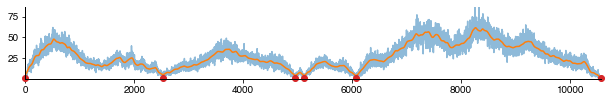

In [531]:
# Identify LD blocks using method adapted from Berisa & Pickrell, 2015
import scipy.signal
import scipy.ndimage as ndimage

M = np.rot90(ukbb_ld_df)
d = np.array([np.trace(M, offset=i) for i in np.arange(-len(M)+1, len(M))])
dm = np.array([np.max(np.diag(M, i)) for i in np.arange(-len(M)+1, len(M))])
w = np.hanning(100)
w /= w.sum()
s = ndimage.convolve1d(d, w)

mask = ndimage.binary_closing(dm < 0.2, np.ones(31), border_value=1)
x = scipy.signal.argrelmin(s)[0]
x = np.r_[0, x[mask[x]], len(s)-1]
ld_bounds = ukbb_ld_df.index[np.round(x/2).astype(int)].map(lambda x: int(x.split('_')[1])).values

ax = qtl.plot.setup_figure(8,1)
qtl.plot.format_plot(ax)
ax.margins(0)
ax.plot(d, alpha=0.5)
ax.plot(s)
ax.scatter(x, np.ones(len(x)), c='tab:red', zorder=2, clip_on=False)

#### Specify colors

In [33]:
track_colors = {
    'HSC': '#00441A',
    'MPP': '#449C3D',
    'LMPP': '#00AF9A',
    'CMP': '#FFC179',
    'GMP': '#FFA300',
    'MEP': '#F5313D',
    'Mono': '#D3441C',
    'Ery': '#8F1337',
    'CLP': '#97D9E9',
    'CD4': '#0181CA',
    'CD8': '#001588',
    'Bcell': '#BA7FD1',
    'NK':   '#480C64',
    'CD34': '#AAAAAA',
}
track_colors = {f"{k} ATACseq":v for k,v in track_colors.items()}

track_colors.update(colors_df['color_hex'].rename(index={k:f"{k} ATACseq" for k in colors_df.index}).to_dict())
track_colors.update(colors_df['color_hex'].rename(index={k:f"{k} H3K27ac" for k in colors_df.index}).to_dict())

pip_colors = {
    'Metabolic': '#915c3d',
    'Lipids': '#36a4b0',
    'Cardiovascular': '#c23c3e',
    'Hematopoietic': '#5d9e5b',
    'Skeletal': '#4d7ca2',
    'Other': '#999999',
    'Cancer': 'tab:orange'    
}
pip_colors.update(colors_df.set_index('tissue_abbrv')['color_hex'].to_dict())
cc = plt.cm.tab20b(np.arange(4,16))
cancer_cat = [
    # 'Age-related diseases',
    'Breast Cancer',
    'Colorectal Cancer',
    # 'Endometrial Cancer',
    'Glioma',
    # 'Keratinocyte Carcinoma',
    'Leukemia',
    'Lung Cancer',
    'Melanoma',
    # 'Myeloma',
    # 'Non-Melanoma Skin Cancer',
    # 'Prostate Cancer',
]
pip_colors.update({c:cc[i] for i,c in enumerate(cancer_cat)})

pip_colors['PTTARY dial-out'] = pip_colors['PTTARY']
pip_colors['eQTLGen'] = pip_colors['WHLBLD']
pip_colors['USM_B'] = 'tab:red'
pip_colors['Th17'] = 'tab:red'
pip_colors['Macrophages'] = 'tab:orange'

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


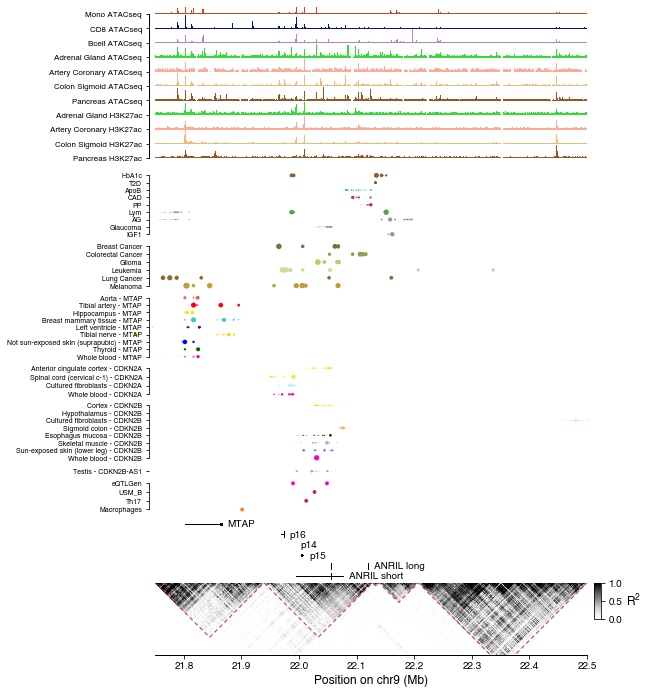

In [536]:
drop_tissues = [
    'Adipose_Subcutaneous',
    'Adipose_Visceral_Omentum',
    'Adrenal_Gland',
    'Artery_Coronary',
    'Brain_Anterior_cingulate_cortex_BA24',
    'Brain_Caudate_basal_ganglia',
    'Brain_Cortex',
    'Brain_Frontal_Cortex_BA9',
    'Brain_Nucleus_accumbens_basal_ganglia',
    'Cells_Cultured_fibroblasts',
    'Colon_Sigmoid',
    'Colon_Transverse',
    'Esophagus_Gastroesophageal_Junction',
    'Esophagus_Mucosa',
    'Esophagus_Muscularis',
    'Heart_Atrial_Appendage',
    'Lung',
    'Muscle_Skeletal',
    'Ovary',
    'Pancreas',
    'Skin_Sun_Exposed_Lower_leg',
    'Spleen',
    'Stomach',
    'Testis',
    'Vagina',
]
ax = qtl.plot.plot_locus_summary(region_str, tracks_dict=coverage_dict,
              track_colors=track_colors, ld_df=ukbb_ld_df, ld_bounds=ld_bounds,
              pip_df=[ukb_df[ukb_df['method'] == 'SUSIE'],
                      locus_gwas_pip_df,
                      gtex_pip_df[(gtex_pip_df['gene_name'] == 'MTAP') & ~gtex_pip_df['tissue_id'].isin(drop_tissues)],
                      # gtex_pip_df[gtex_pip_df['gene_name'] == 'MTAP'],
                      gtex_pip_df[gtex_pip_df['gene_name'] == 'CDKN2A'],
                      gtex_pip_df[gtex_pip_df['gene_name'] == 'CDKN2B'],
                      gtex_pip_df[gtex_pip_df['gene_name'] == 'CDKN2B-AS1'],
                      blood_pip_df], 
              pip_colors=pip_colors, pip_legend=False,
              gene=p16_locus_genes, ld_marker_size=0.1, dl=2.25)
plt.savefig('GWAS_catalog_cancer_locus_PIPs.condensed.pdf', dpi=300)